<a href="https://colab.research.google.com/github/anilpomar/Full-Stack-Gen-AI-BootCamp-KrishNaik-/blob/main/End_to_End_LLM_Fine_Tuning_Techniques_Non_Instruction%2CInstruction_And_Preference_Data_using_Huggingface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
print("Test Ok")

Test Ok


1. dataclass
2. enum class
3. pydantic class
4. typedict class
5. abstract class

Above Classes are used for Data Validation And Configuration

In [5]:
# ============================================================
# 1. Install required libraries
# ============================================================
# PyMuPDF: PDF text extraction
# datasets: Hugging Face dataset creation
# transformers/accelerate: model, tokenizer, Trainer
# peft: LoRA/QLoRA adapters
# bitsandbytes: 4-bit/8-bit quantized loading

!pip install -q -U pymupdf datasets transformers accelerate peft bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.6 MB/s eta 0:00:00


In [3]:
#This Code Ignore all warnings that occured
import warnings
warnings.filterwarnings("ignore")

In [6]:
# ============================================================
# 2. Imports
# ============================================================

import os
import re
import gc
import math
import json
import random
import unicodedata
from dataclasses import dataclass, asdict
from typing import List, Dict, Any

import fitz  # PyMuPDF
import torch
from datasets import Dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    set_seed,
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
)

In [70]:
from google.colab import userdata
WriteToken=userdata.get('HuggingFace_Write')

In [7]:
# ============================================================
# 3. Global configuration
# ============================================================
# Keep all important parameters in one place.
# This makes the notebook easier to debug, reproduce, and productionize.
# In Modular coding all these parameters will be placed in config or external confiuration

from dataclasses import dataclass, asdict

@dataclass
class Config:
    # Path of the pharma PDF file that will be used as the raw domain corpus.
    pdf_path: str = "/content/Metformin-Lipid-Therapy-Knowledge.pdf"

    # Base causal language model that we will fine-tune on pharma-domain text.
    #Any model can be used here
    model_name: str = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"

    # Directory where training checkpoints will be saved during fine-tuning.
    output_dir: str = "/content/pharma_tinyllama_lora_output"

    # Directory where the final trained LoRA adapter will be saved.
    adapter_dir: str = "/content/pharma_tinyllama_lora_adapter"

    # Directory where cleaned and processed training data will be saved.
    processed_data_dir: str = "/content/pharma_processed_data"

    # Minimum paragraph length required to keep a paragraph for training.
    min_chars_per_paragraph: int = 80

    # Number of tokens in each training block for causal language modeling.
    block_size: int = 512

    # Percentage of data used for validation instead of training.
    test_size: float = 0.15

    # Random seed used to make splitting and training more reproducible.
    seed: int = 42

    # LoRA rank; controls the size and capacity of the trainable adapter.
    lora_r: int = 16

    # LoRA scaling factor; controls the strength of the LoRA update.
    lora_alpha: int = 32

    # Dropout applied inside LoRA layers to reduce overfitting.
    lora_dropout: float = 0.05

    # Number of times the model will see the complete training dataset.
    num_train_epochs: float = 3.0

    # Number of training samples processed per GPU/device at one time.
    per_device_train_batch_size: int = 1

    # Number of validation samples processed per GPU/device at one time.
    per_device_eval_batch_size: int = 1

    # Number of small batches accumulated before one optimizer update.
    gradient_accumulation_steps: int = 8

    # Step size used by the optimizer to update trainable LoRA weights.
    learning_rate: float = 2e-4

    # Fraction of early training steps used to gradually increase learning rate.
    warmup_ratio: float = 0.03

    # Regularization value used to prevent weights from becoming too large.
    weight_decay: float = 0.01

    # Number of training steps after which logs will be printed.
    logging_steps=1
    logging_first_step=True

    # Number of training steps after which validation will be performed.
    eval_steps: int = 10

    # Number of training steps after which a checkpoint will be saved.
    save_steps: int = 25

    # Maximum number of checkpoints to keep; older checkpoints will be deleted.
    save_total_limit: int = 2

    # Maximum number of training steps; -1 means train using num_train_epochs.
    max_steps: int = -1

In [8]:
config = Config()

In [62]:
# ============================================================
# Hugging Face repo names
# ============================================================

HF_USERNAME = "AnilPomar14"

BASE_MODEL_NAME = config.model_name

# Stage 1: Non-instruction LoRA adapter
HF_REPO_NON_INSTRUCTION_ADAPTER = f"{HF_USERNAME}/pharma-tinyllama-non-instruction-lora-adapter"

# Stage 1 merged model
HF_REPO_NON_INSTRUCTION_MERGED = f"{HF_USERNAME}/pharma-tinyllama-non-instruction-merged"

# Stage 2: Instruction LoRA adapter
HF_REPO_INSTRUCTION_ADAPTER = f"{HF_USERNAME}/pharma-tinyllama-instruction-lora-adapter"

# Stage 2 merged model
HF_REPO_INSTRUCTION_MERGED = f"{HF_USERNAME}/pharma-tinyllama-instruction-merged"

# Stage 3: DPO preference LoRA adapter
HF_REPO_DPO_ADAPTER = f"{HF_USERNAME}/pharma-tinyllama-dpo-lora-adapter"

# Stage 3 final merged model
HF_REPO_DPO_MERGED = f"{HF_USERNAME}/pharma-tinyllama-dpo-merged"

print(HF_REPO_NON_INSTRUCTION_ADAPTER)
print(HF_REPO_INSTRUCTION_ADAPTER)
print(HF_REPO_DPO_ADAPTER)

AnilPomar14/pharma-tinyllama-non-instruction-lora-adapter
AnilPomar14/pharma-tinyllama-instruction-lora-adapter
AnilPomar14/pharma-tinyllama-dpo-lora-adapter


In [9]:
config
#print(json.dumps(asdict(config), indent=2))

Config(pdf_path='/content/Metformin-Lipid-Therapy-Knowledge.pdf', model_name='TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T', output_dir='/content/pharma_tinyllama_lora_output', adapter_dir='/content/pharma_tinyllama_lora_adapter', processed_data_dir='/content/pharma_processed_data', min_chars_per_paragraph=80, block_size=512, test_size=0.15, seed=42, lora_r=16, lora_alpha=32, lora_dropout=0.05, num_train_epochs=3.0, per_device_train_batch_size=1, per_device_eval_batch_size=1, gradient_accumulation_steps=8, learning_rate=0.0002, warmup_ratio=0.03, weight_decay=0.01, eval_steps=10, save_steps=25, save_total_limit=2, max_steps=-1)

In [10]:
Config

__main__.Config

In [11]:
Config.block_size


512

In [12]:
Config.output_dir

'/content/pharma_tinyllama_lora_output'

In [13]:
os.makedirs(config.output_dir, exist_ok=True)
os.makedirs(config.adapter_dir, exist_ok=True)
os.makedirs(config.processed_data_dir, exist_ok=True)

In [15]:
#Check whether Test Data PDF File is available

if not os.path.exists(config.pdf_path):
    print(f"PDF not found at: {config.pdf_path}")
else:
    print(f"PDF found: {config.pdf_path}")

PDF found: /content/Metformin-Lipid-Therapy-Knowledge.pdf


In [16]:
# # ============================================================
# #  Extract text from PDF
# # ============================================================
from typing import List, Dict, Any
import fitz  # PyMuPDF
def extract_pdf_pages(pdf_path: str) -> List[Dict[str, Any]]:
    # Extract page-level text from a PDF.
    pages = []
    with fitz.open(pdf_path) as doc:
        for page_index, page in enumerate(doc, start=1):
            text = page.get_text("text")
            text = text.strip() if text else ""
            if text:
                pages.append({
                    "page": page_index,
                    "text": text,
                    "char_count": len(text),
                })
    return pages

In [17]:
config.pdf_path

'/content/Metformin-Lipid-Therapy-Knowledge.pdf'

In [18]:
#Read PDF Extract pages from it.
pdf_pages=extract_pdf_pages(config.pdf_path)

print(f"Total pages with extracted text: {len(pdf_pages)}")
print("Page-level character counts:")
for item in pdf_pages:
    print(f"Page {item['page']}: {item['char_count']} characters")

Total pages with extracted text: 6
Page-level character counts:
Page 1: 2244 characters
Page 2: 2889 characters
Page 3: 2636 characters
Page 4: 2416 characters
Page 5: 2613 characters
Page 6: 2761 characters


In [19]:
#Check Data from loaded Pages object

print(pdf_pages[0]["text"])


Metformin is one of the most widely prescribed oral antihyperglycemic agents.​
 Its primary mechanism of action involves the activation of AMP-activated protein kinase 
(AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation 
while inhibiting hepatic gluconeogenesis.​
 Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes 
and display anti-inflammatory properties.​
 Recent studies also suggest potential anticancer effects through inhibition of the mTOR 
signaling pathway and suppression of tumor angiogenesis. 
 
Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in 
significant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to 
monotherapy.​
 Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal 
wall, reducing cholesterol absorption, while Atorvastatin inhibits hepatic HMG-CoA reductase, 
suppressing endogenous cho

**Text Cleaning**

**Now we need to Clean the Data to avoid anomalies**

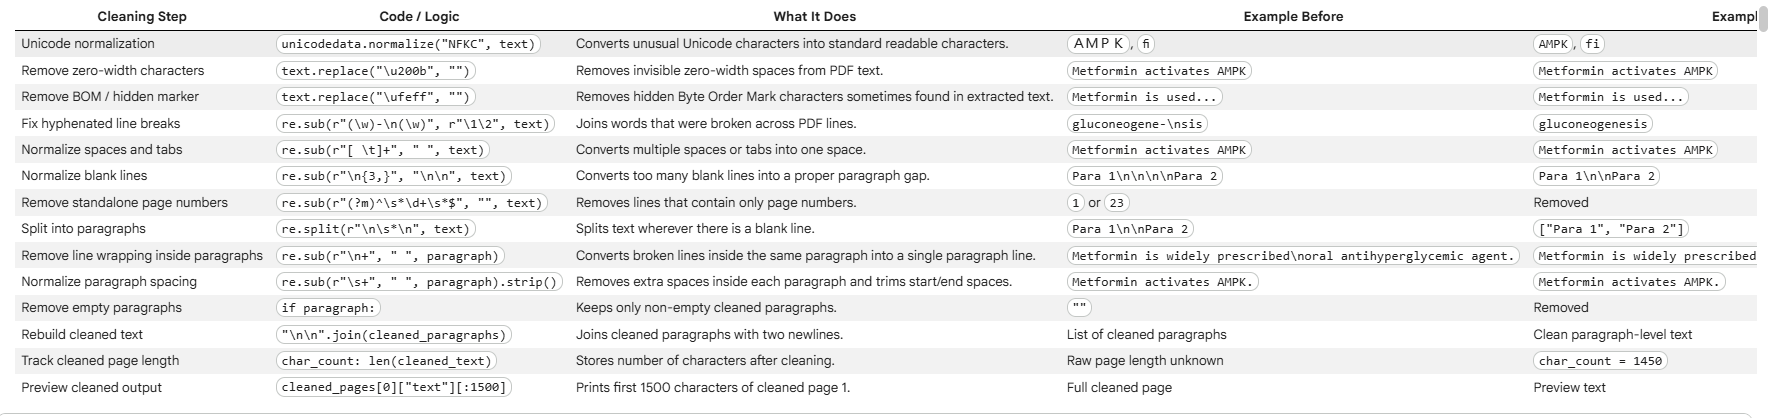


In [20]:
#Text Cleaning

import re
import unicodedata

def clean_pdf_text(text: str) -> str:
    # Standardize Unicode text so visually similar characters are treated consistently.
    # Example: "ＡＭＰＫ" becomes "AMPK" and "ﬁ" becomes "fi".
    text = unicodedata.normalize("NFKC", text)


    # Remove invisible characters that may appear during PDF text extraction.
    # It is very important to remove to avoid confusion to Tokenizer.
    text = text.replace("\u200b", "").replace("\ufeff", "")

    # Join words broken by line hyphenation, e.g., "gluconeogene-\nsis" -> "gluconeogenesis".
    text = re.sub(r"(\w)-\n(\w)", r"\1\2", text)

    # Replace multiple spaces/tabs with a single space.
    text = re.sub(r"[ \t]+", " ", text)

    # Convert three or more newlines into a standard paragraph break.
    text = re.sub(r"\n{3,}", "\n\n", text)

    # Remove lines that contain only page numbers.
    text = re.sub(r"(?m)^\s*\d+\s*$", "", text)

    # Split text into paragraphs, clean each paragraph, and remove empty ones.
    paragraphs = []
    for paragraph in re.split(r"\n\s*\n", text):
        paragraph = re.sub(r"\n+", " ", paragraph)
        paragraph = re.sub(r"\s+", " ", paragraph).strip()

        if paragraph:
            paragraphs.append(paragraph)

    # Join cleaned paragraphs with one blank line between them.
    return "\n\n".join(paragraphs)

In [21]:
cleaned_pages = []

In [22]:
for page in pdf_pages:
    cleaned_text = clean_pdf_text(page["text"])
    cleaned_pages.append({
        "page": page["page"],
        "text": cleaned_text,
        "char_count": len(cleaned_text),
    })

    print("Total cleaned pages:", len(cleaned_pages))

Total cleaned pages: 1
Total cleaned pages: 2
Total cleaned pages: 3
Total cleaned pages: 4
Total cleaned pages: 5
Total cleaned pages: 6


In [23]:
# Check First Page from Cleaned Pages
print(cleaned_pages[0]["text"])

Metformin is one of the most widely prescribed oral antihyperglycemic agents. Its primary mechanism of action involves the activation of AMP-activated protein kinase (AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while inhibiting hepatic gluconeogenesis. Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes and display anti-inflammatory properties. Recent studies also suggest potential anticancer effects through inhibition of the mTOR signaling pathway and suppression of tumor angiogenesis.

Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in significant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to monotherapy. Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal wall, reducing cholesterol absorption, while Atorvastatin inhibits hepatic HMG-CoA reductase, suppressing endogenous cholesterol synthesis

**To Perform Non-Instruction Fine tuning we require Text Column which we need to add to cleaned_pages collection**

In [24]:
# ============================================================
# Split cleaned pages into paragraphs
# ============================================================
# This step converts cleaned page-level text into paragraph-level records.

def split_into_paragraph_records(cleaned_pages, min_chars=80):
    paragraph_records = []

    for page in cleaned_pages:
        # Split page text into paragraphs using blank lines.
        paragraphs = page["text"].split("\n\n")

        for paragraph_index, paragraph in enumerate(paragraphs, start=1):
            # Remove extra spaces from the beginning and end.
            paragraph = paragraph.strip()

            # Skip very short paragraphs because they are usually headings, page numbers, or noise.
            if len(paragraph) < min_chars:
                continue

            # Store each useful paragraph with basic metadata.
            paragraph_records.append({
                "text": paragraph,
                "source_page": page["page"],
                "paragraph_id": paragraph_index,
                "char_count": len(paragraph),
            })

    return paragraph_records

In [26]:
paragraph_records = split_into_paragraph_records(cleaned_pages)
print(len(paragraph_records))

9


**Checking the data as this will be final data set used for Training**

In [27]:
for record in paragraph_records[:4]:
    print("=" * 60)
    print(f"Page: {record['source_page']} | Paragraph: {record['paragraph_id']} | Characters: {record['char_count']}")
    print(record["text"])

Page: 1 | Paragraph: 1 | Characters: 575
Metformin is one of the most widely prescribed oral antihyperglycemic agents. Its primary mechanism of action involves the activation of AMP-activated protein kinase (AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while inhibiting hepatic gluconeogenesis. Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes and display anti-inflammatory properties. Recent studies also suggest potential anticancer effects through inhibition of the mTOR signaling pathway and suppression of tumor angiogenesis.
Page: 1 | Paragraph: 2 | Characters: 598
Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in significant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to monotherapy. Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal wall, reducing cholesterol absorption, while Atorvastatin

In [28]:
# ============================================================
# Save extracted and cleaned corpus for auditability
# ============================================================
# In real projects, always save intermediate datasets.
# This helps with reproducibility, debugging, and compliance review.

raw_pages_path = os.path.join(config.processed_data_dir, "pdf_pages_raw.jsonl")
paragraphs_path = os.path.join(config.processed_data_dir, "pharma_paragraph_process.jsonl")

with open(raw_pages_path, "w", encoding="utf-8") as f:
    for item in pdf_pages:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

with open(paragraphs_path, "w", encoding="utf-8") as f:
    for item in paragraph_records:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"Saved raw pages to: {raw_pages_path}")
print(f"Saved cleaned paragraph corpus to: {paragraphs_path}")

Saved raw pages to: /content/pharma_processed_data/pdf_pages_raw.jsonl
Saved cleaned paragraph corpus to: /content/pharma_processed_data/pharma_paragraph_process.jsonl


**The Data which is cleaned and processed is not HuggingFace Compatible data**

*Now need to Convert to Huggingface format*

In [29]:
# ============================================================
# Create Hugging Face Dataset
# ============================================================
from datasets import Dataset
if len(paragraph_records) < 2:
    raise ValueError(
        "The extracted corpus is too small. Please provide a larger pharma PDF or lower min_chars_per_paragraph."
    )
text_dataset = Dataset.from_list(paragraph_records)

In [30]:
#Now Dataset is Huggingface Format Compatible
print(text_dataset)

Dataset({
    features: ['text', 'source_page', 'paragraph_id', 'char_count'],
    num_rows: 9
})


In [31]:
print(text_dataset[0])

{'text': 'Metformin is one of the most widely prescribed oral antihyperglycemic agents. Its primary mechanism of action involves the activation of AMP-activated protein kinase (AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while inhibiting hepatic gluconeogenesis. Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes and display anti-inflammatory properties. Recent studies also suggest potential anticancer effects through inhibition of the mTOR signaling pathway and suppression of tumor angiogenesis.', 'source_page': 1, 'paragraph_id': 1, 'char_count': 575}


**We have Completed Data Injection Process**

***Now Lets Split data for Training And Validation***

In [32]:
# ============================================================
# Train/eval split
# ============================================================
# Even for small demos, keep an evaluation set.
# This gives us validation loss and perplexity.
# Here 15% of data will be allocated to Validation and 85% for Traning.
split_dataset = text_dataset.train_test_split(test_size=config.test_size, seed=config.seed)

from datasets import DatasetDict

dataset = DatasetDict({
    "train": split_dataset["train"],
    "validation": split_dataset["test"],
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'source_page', 'paragraph_id', 'char_count'],
        num_rows: 7
    })
    validation: Dataset({
        features: ['text', 'source_page', 'paragraph_id', 'char_count'],
        num_rows: 2
    })
})


**Load tokenizer**

The tokenizer converts text into token IDs.

For causal language modeling, the model learns:

```text
Given previous tokens, predict the next token.
```

This is why we call it **non-instruction causal LM fine-tuning**.

## What Does `512` Mean in Text Packing?

In this notebook, `512` means the **sequence length** or **block size** used for causal language model training.

It is **not the embedding size**.

It simply means:

> Each training example will contain 512 tokens.

---

## Example

Suppose the tokenizer converts our pharma text into 1,300 tokens:

```text
[token_1, token_2, token_3, ..., token_1300]?

if we set:

block_size = 512

then the tokens are split like this:

Block 1 = token 1 to token 512
Block 2 = token 513 to token 1024
Remaining tokens = token 1025 to token 1300

Is 512 Padding?

Not exactly.

512 is the target length of each training block.

If we use text packing, we try to fill each block with real tokens, so padding is reduced.

Without packing:

Paragraph 1 = 100 tokens + 412 padding tokens
Paragraph 2 = 200 tokens + 312 padding tokens

With packing:

Block 1 = 512 real tokens
Block 2 = 512 real tokens

So 512 is the fixed token length used to make training efficient.

Is 512 Embedding Size?

No.

Embedding size means the hidden vector dimension of the model.

For example, a model may convert each token into a vector like:

token → 2048-dimensional vector

That 2048 is embedding/hidden size.

But 512 here means:

How many tokens we give to the model at one time

**Pad token**
When are abmormal words in sentence passed to Model, it takes maxium words sentence and set 0 to other sentence which has less words than max words sentence.


```markdown
Ex:
***Before Padding***
I love India
I Love India Anil
I love India Anil Pomar

**After Applying padding **

I love India  0    0
I Love India Anil  0
I love India Anil Pomar
```

In [33]:
# ============================================================
# Load tokenizer
#    (which Converts Text into Tokens)
#    Here we load Model Into VRAM If want to load into Disk we need to use Snapshot
# ============================================================

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(config.model_name, use_fast=True)

# Some Llama-style models do not define a pad token.
# For causal LM fine-tuning, using EOS as PAD is a common practical choice.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [34]:
tokenizer.eos_token

'</s>'

In [35]:
print(f"Tokenizer loaded: {config.model_name}")
print(f"Vocab size: {len(tokenizer)}")
print(f"Pad token: {tokenizer.pad_token} | Pad token id: {tokenizer.pad_token_id}")
print(f"EOS token: {tokenizer.eos_token} | EOS token id: {tokenizer.eos_token_id}")

Tokenizer loaded: TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T
Vocab size: 32000
Pad token: </s> | Pad token id: 2
EOS token: </s> | EOS token id: 2


In [36]:
# ============================================================
# Tokenization and text packing
# ============================================================
def tokenize_function(examples):
    # Tokenize text without padding. Padding is handled dynamically by the collator.
    return tokenizer(examples["text"])

In [37]:
tokenized_datasets = dataset.map(
    tokenize_function,
    remove_columns=dataset["train"].column_names,
    desc="Tokenizing text corpus",
)

Tokenizing text corpus:   0%|          | 0/7 [00:00<?, ? examples/s]

Tokenizing text corpus:   0%|          | 0/2 [00:00<?, ? examples/s]

| Parameter                                       | Meaning                                                                                                                               |
| ----------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| `tokenize_function`                             | This function converts each text example into token IDs.                                                                              |
| `batched=True`                                  | The function processes multiple rows at once instead of one row at a time. This makes tokenization faster.                            |
| `remove_columns=datasets["train"].column_names` | After tokenization, the original dataset columns are removed. Only tokenized columns such as `input_ids` and `attention_mask` remain. |
| `desc="Tokenizing text corpus"`                 | This message is shown in the progress bar so we can understand that tokenization is currently running.                                |


In [38]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 7
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2
    })
})

In [39]:
tokenized_datasets['train']['input_ids'][0]

[1,
 1963,
 22824,
 28460,
 26101,
 3630,
 448,
 9305,
 29871,
 29945,
 9305,
 29871,
 29945,
 448,
 319,
 29902,
 297,
 360,
 11124,
 8565,
 22205,
 322,
 1963,
 22824,
 346,
 329,
 936,
 390,
 29987,
 29928,
 29936,
 1963,
 22824,
 29899,
 7247,
 1034,
 13364,
 6081,
 363,
 2888,
 2691,
 29899,
 29873,
 27964,
 322,
 390,
 10051,
 7639,
 362,
 29889,
 7519,
 29883,
 1288,
 2793,
 871,
 29936,
 451,
 16083,
 9848,
 29889,
 17157,
 29769,
 3012,
 928,
 616,
 21082,
 338,
 10231,
 368,
 1304,
 297,
 1374,
 22824,
 346,
 329,
 936,
 5925,
 304,
 27599,
 20853,
 1199,
 29892,
 1301,
 924,
 290,
 1199,
 29892,
 3279,
 290,
 1199,
 29892,
 17135,
 17292,
 327,
 7384,
 29892,
 22233,
 9562,
 29892,
 322,
 24899,
 936,
 20035,
 29889,
 512,
 3646,
 29769,
 29892,
 4933,
 6509,
 4733,
 508,
 7536,
 277,
 675,
 2531,
 267,
 470,
 3279,
 1144,
 393,
 1122,
 1708,
 3269,
 284,
 16178,
 297,
 17135,
 4768,
 3002,
 29889,
 4525,
 27303,
 526,
 9324,
 6419,
 746,
 23387,
 411,
 17986,
 8845,
 29892,

In [40]:
 # Join all token IDs from multiple examples into one long list.

def create_training_blocks(tokenized_examples):
    all_input_ids = []
    all_attention_masks = []

    for input_ids in tokenized_examples["input_ids"]:
        all_input_ids.extend(input_ids)

    for attention_mask in tokenized_examples["attention_mask"]:
        all_attention_masks.extend(attention_mask)

    # Calculate how many complete blocks we can create.
    total_tokens = len(all_input_ids)
    usable_tokens = (total_tokens // config.block_size) * config.block_size

    # If we do not have enough tokens to create even one block, return empty data.
    if usable_tokens == 0:
        return {
            "input_ids": [],
            "attention_mask": [],
            "labels": [],
        }

    # Keep only tokens that can fit into complete fixed-size blocks.
    all_input_ids = all_input_ids[:usable_tokens]
    all_attention_masks = all_attention_masks[:usable_tokens]

    # Split the long token list into fixed-size training blocks.
    input_id_blocks = []
    attention_mask_blocks = []

    for start_index in range(0, usable_tokens, config.block_size):
        end_index = start_index + config.block_size

        input_id_blocks.append(all_input_ids[start_index:end_index])
        attention_mask_blocks.append(all_attention_masks[start_index:end_index])

    # For causal language modeling, labels are the same as input IDs.
    # The model uses these labels to learn next-token prediction.
    labels = input_id_blocks.copy()

    return {
        "input_ids": input_id_blocks,
        "attention_mask": attention_mask_blocks,
        "labels": labels,
    }

In [41]:
final_dataset = tokenized_datasets.map(
    create_training_blocks,
    batched=True,
    desc=f"Creating fixed-size training blocks of {config.block_size} tokens",
)

Creating fixed-size training blocks of 512 tokens:   0%|          | 0/7 [00:00<?, ? examples/s]

Creating fixed-size training blocks of 512 tokens:   0%|          | 0/2 [00:00<?, ? examples/s]

## What Does This Function Do?

This function converts tokenized text into **fixed-size training blocks**.

First, it joins all token IDs into one long sequence.  
Then, it cuts that long sequence into equal blocks of `config.block_size` tokens.

For causal language modeling, the labels are copied from `input_ids` because the model learns to predict the next token.

---

## Example

Suppose we have these tokenized inputs:

```text
Input token lists:

[10, 20, 30]
[40, 50]
[60, 70, 80, 90]

After joining all token lists together:

[10, 20, 30, 40, 50, 60, 70, 80, 90]

If:

block_size = 4

Then the final training blocks become:

Block 1 = [10, 20, 30, 40]
Block 2 = [50, 60, 70, 80]

The remaining token is:

[90]

This token is dropped because it cannot form a complete block of 4 tokens.

Simple Summary

This step prepares the final causal language modeling dataset by converting many small tokenized examples into equal-length token blocks.

In [42]:
sample = final_dataset["train"][0]

In [43]:
print("Keys:", sample.keys())
print("input_ids length:", len(sample["input_ids"]))
print("labels length:", len(sample["labels"]))
print("Decoded sample preview:\n")
print(tokenizer.decode(sample["input_ids"][:250]))

Keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
input_ids length: 512
labels length: 512
Decoded sample preview:

<s> Pharma Domain Training Data - Page 5 Page 5 - AI in Drug Discovery and Pharmaceutical R&D; Pharma-domain corpus extension for custom fine-tuning and RAG experimentation. Educational content only; not medical advice. Target identification Artificial intelligence is increasingly used in pharmaceutical research to analyze genomics, transcriptomics, proteomics, disease phenotypes, chemical libraries, and clinical datasets. In target identification, machine learning models can prioritize genes or proteins that may play causal roles in disease biology. These predictions are strengthened when integrated with experimental validation, pathway analysis, human genetics, and disease-relevant biomarkers. Molecular screening In early discovery, deep learning can support virtual screening by predicting protein-ligand binding affinity, molecular properties, toxicity signals,

## Load Model for QLoRA Training

In this step, we load the base model for fine-tuning.

If GPU is available, we load the model in **4-bit mode**.

This helps because:

- It uses less GPU memory
- It allows us to fine-tune larger models on limited hardware
- It is useful for Colab or small GPU environments
- It works well with LoRA/QLoRA fine-tuning

If GPU is not available, the model will load normally on CPU, but training will be much slower.

In [44]:
# ============================================================
# Load base model
# ============================================================
import torch
use_cuda = torch.cuda.is_available()
print("CUDA available:", use_cuda)
if use_cuda:
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [45]:
# Clear memory before loading the model.
import gc
gc.collect()
if use_cuda:
    torch.cuda.empty_cache()

**BitsAndBytesConfig**
is a configuration class from HuggingFace Transformers that lets you load large models in lower precision (quantized format) to dramatically reduce memory usage — making it possible to run huge LLMs on consumer GPUs

***The Core Problem It Solves***
Loading a model normally uses 32-bit floats (FP32) per weight. A 7B parameter model in FP32 needs:

7,000,000,000 params × 4 bytes = 28 GB of GPU memory ❌

Most consumer GPUs (RTX 3060, 4070, etc.) only have 8-12 GB. You can't fit it.
BitsAndBytesConfig lets you load the same model in 4-bit or 8-bit:

7,000,000,000 params × 0.5 bytes (4-bit) = 3.5 GB ✅

Now it fits on a small GPU.

**prepare_model_for_kbit_training**
It is a function from the PEFT library that prepares a quantized model (4-bit or 8-bit) for fine-tuning. Without it, training a quantized model would either crash or produce poor results.

***Why It's Needed***
When you load a model with BitsAndBytesConfig, the weights are frozen in low precision (4-bit/8-bit). You can't train them directly because:
Quantized model (4-bit)
        ↓
Weights are integers, not floats
        ↓
Gradients can't flow through integer math
        ↓
Training crashes or produces garbage

prepare_model_for_kbit_training fixes this by preparing the model properly for gradient computation.


In [46]:
from transformers import AutoModelForCausalLM

if use_cuda:
    from transformers import BitsAndBytesConfig
    from peft import prepare_model_for_kbit_training

    # Configure 4-bit quantization to reduce GPU memory usage.
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    # Load the base model in 4-bit mode on available GPU devices.
    base_model = AutoModelForCausalLM.from_pretrained(
        config.model_name,
        quantization_config=quantization_config,
        device_map="auto",
        trust_remote_code=True,
    )

    # Prepare the quantized model for stable LoRA/QLoRA training.
    base_model = prepare_model_for_kbit_training(base_model)

else:
    # Load the base model normally when GPU is not available.
    base_model = AutoModelForCausalLM.from_pretrained(
        config.model_name,
        torch_dtype=torch.float32,
        trust_remote_code=True,
    )

# Disable cache during training to reduce memory usage and avoid training warnings.
base_model.config.use_cache = False

print("Base model loaded successfully.")

model.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

Base model loaded successfully.


In [48]:
# ============================================================
# Apply LoRA (Low Rank Adaption) adapters
# ============================================================
# LoRA trains a small number of adapter parameters instead of updating all base model weights.
# This is cheaper than full fine-tuning and is widely used in real projects.
from peft import LoraConfig
from peft import TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=config.lora_r,
    lora_alpha=config.lora_alpha,
    lora_dropout=config.lora_dropout,
    bias="none",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)


**Why need of LoRA adapter and Its Usuage?**

 Applies the LoRA configuration (defined by lora_config) to your base_model. Instead of directly modifying all the weights of the base_model during fine-tuning (which would be computationally expensive and require a lot of memory), get_peft_model creates a new model that:

Keeps most of the base_model's weights frozen.
Introduces small, trainable adapter layers (LoRA adapters) into specific parts of the base_model (as specified in your lora_config, e.g., q_proj, k_proj, v_proj).
This approach significantly reduces the number of parameters that need to be trained, making fine-tuning much faster and more memory-efficient, while still achieving performance comparable to full fine-tuning.

In [49]:
from peft import get_peft_model
model = get_peft_model(base_model, lora_config)

In [50]:
model.print_trainable_parameters()

trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


As per above Output just fine tuning of
1.1338 percent of params (or) weights is enough.

In [51]:
# ============================================================
# Data collator
# ============================================================
from transformers import DataCollatorForLanguageModeling
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

## Why Do We Need `DataCollatorForLanguageModeling`?

After tokenization and text packing, our dataset contains token IDs in a training-ready structure.

However, the `Trainer` still needs a component that can take multiple examples from the dataset and convert them into a proper batch during training.

That component is called a **data collator**.

```python
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)
What Does the Data Collator Do?

The data collator prepares mini-batches for the model.

It handles things like:

Collecting multiple training examples together
Padding sequences if required
Converting examples into tensors
Preparing labels for language modeling
Example

Suppose our packed dataset has training examples like this:

Example 1 = 512 tokens
Example 2 = 512 tokens
Example 3 = 512 tokens

During training, the Trainer may take two examples at a time:

Batch = Example 1 + Example 2

The data collator converts them into tensors like:

input_ids shape      = [2, 512]
attention_mask shape = [2, 512]
labels shape         = [2, 512]

This is the format the model expects during training.

Why mlm=False?

mlm means Masked Language Modeling.

Masked Language Modeling is used for BERT-style models.

Example:

Metformin is used for [MASK].

The model predicts the masked word:

diabetes

But we are using TinyLlama, which is a causal language model.

Causal language models learn by predicting the next token from left to right.

Example:

Metformin → is
Metformin is → used
Metformin is used → for
Metformin is used for → diabetes

So we set:

mlm=False

This tells Hugging Face:

Do not use BERT-style masked language modeling. Use causal language modeling instead.

Why Is This Needed Even After Tokenization and Packing?

Tokenization converts text into token IDs.

Text packing groups token IDs into fixed-size blocks.

But the data collator prepares those blocks into actual training batches.

So the flow is:

Raw pharma text
   ↓
Tokenization
   ↓
Token IDs
   ↓
Text packing
   ↓
Fixed-size training blocks
   ↓
Data collator
   ↓
Mini-batches for Trainer
   ↓
Model training

In [53]:
# ============================================================
# Training arguments
# ============================================================
# These settings are designed for a small classroom/demo run.
# For larger corpora, increase dataset size, epochs, and evaluation frequency carefully.

from transformers import TrainingArguments

In [54]:
training_kwargs = dict(
    output_dir=config.output_dir,
    num_train_epochs=config.num_train_epochs,
    max_steps=config.max_steps,
    per_device_train_batch_size=config.per_device_train_batch_size,
    per_device_eval_batch_size=config.per_device_eval_batch_size,
    gradient_accumulation_steps=config.gradient_accumulation_steps,
    learning_rate=config.learning_rate,
    warmup_steps=5,
    weight_decay=config.weight_decay,

    # Log training loss at every step for small demo datasets.
    logging_steps=1,
    logging_first_step=True,

    eval_steps=config.eval_steps,
    save_steps=config.save_steps,
    save_total_limit=config.save_total_limit,
    fp16=use_cuda,
    bf16=False,
    report_to="none",
    remove_unused_columns=False,
)

In [55]:
from transformers import TrainingArguments
training_args = TrainingArguments(**training_kwargs)

In [56]:
# ============================================================
#  Build Trainer
# ============================================================
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=final_dataset["train"],
    eval_dataset=final_dataset["validation"],
    data_collator=data_collator,
)
print("Trainer is ready.")

Trainer is ready.


In [57]:
# ============================================================
# Start training
# ============================================================
train_result = trainer.train()
print("Training completed.")

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
1,2.148971
2,2.148971
3,2.124540


Training completed.


In [58]:
for log in trainer.state.log_history:
    print(log)

{'loss': 2.14897084236145, 'grad_norm': 0.6650739312171936, 'learning_rate': 0.0, 'epoch': 1.0, 'step': 1}
{'loss': 2.1489710807800293, 'grad_norm': 0.6677411198616028, 'learning_rate': 4e-05, 'epoch': 2.0, 'step': 2}
{'loss': 2.124540090560913, 'grad_norm': 0.6438169479370117, 'learning_rate': 8e-05, 'epoch': 3.0, 'step': 3}
{'train_runtime': 18.4255, 'train_samples_per_second': 0.977, 'train_steps_per_second': 0.163, 'total_flos': 57901993426944.0, 'train_loss': 2.1408273379007974, 'epoch': 3.0, 'step': 3}


In [59]:
# ============================================================
# 19. Save adapter and tokenizer
# ============================================================
trainer.model.save_pretrained(config.adapter_dir)
tokenizer.save_pretrained(config.adapter_dir)

('/content/pharma_tinyllama_lora_adapter/tokenizer_config.json',
 '/content/pharma_tinyllama_lora_adapter/tokenizer.json')

In [60]:
print(f"LoRA adapter saved to: {config.adapter_dir}")
print("Saved files:")
print(os.listdir(config.adapter_dir))

LoRA adapter saved to: /content/pharma_tinyllama_lora_adapter
Saved files:
['adapter_config.json', 'adapter_model.safetensors', 'tokenizer.json', 'README.md', 'tokenizer_config.json']


In [72]:
import os

# ============================================================
# Push Stage 1 non-instruction LoRA adapter to Hugging Face
# ============================================================

trainer.model.push_to_hub(
    HF_REPO_NON_INSTRUCTION_ADAPTER,
    private=True,
    token=WriteToken
)


print("Stage 1 non-instruction LoRA adapter pushed to:")
print(HF_REPO_NON_INSTRUCTION_ADAPTER)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 34.5kB / 50.5MB            

Stage 1 non-instruction LoRA adapter pushed to:
AnilPomar14/pharma-tinyllama-non-instruction-lora-adapter


In [73]:
# ============================================================
# Reload base model + LoRA adapter correctly
# ============================================================
# Clean old objects to free memory.

del trainer

try:
    del model
    del base_model
except NameError:
    pass

gc.collect()

if use_cuda:
    torch.cuda.empty_cache()

**Inference Model Now**

In [74]:
from transformers import AutoTokenizer
inference_tokenizer = AutoTokenizer.from_pretrained(config.adapter_dir, use_fast=True)

if inference_tokenizer.pad_token is None:
    inference_tokenizer.pad_token = inference_tokenizer.eos_token

In [75]:
if use_cuda:
    inference_base_model = AutoModelForCausalLM.from_pretrained(
        config.model_name,
        quantization_config=BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        ),
        device_map="auto",
        trust_remote_code=True,
    )
else:
    inference_base_model = AutoModelForCausalLM.from_pretrained(
        config.model_name,
        torch_dtype=torch.float32,
        trust_remote_code=True,
    )

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [76]:
from peft import PeftModel
inference_model = PeftModel.from_pretrained(inference_base_model, config.adapter_dir)

In [77]:
inference_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [78]:
print("Base model + LoRA adapter loaded successfully for inference.")

Base model + LoRA adapter loaded successfully for inference.


In [79]:
# ============================================================
# Inference helper
# ============================================================
# Since this is non-instruction fine-tuning, prompts should look like text continuations,
# not chat-style questions.

def generate_completion(prompt: str, max_new_tokens: int = 120) -> str:
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Convert prompt text into token IDs.
    inputs = inference_tokenizer(prompt, return_tensors="pt").to(device)

    # Generate text without calculating gradients because we are doing inference, not training.
    with torch.no_grad():
        outputs = inference_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=inference_tokenizer.eos_token_id,
        )

    # Convert generated token IDs back into readable text.
    return inference_tokenizer.decode(outputs[0], skip_special_tokens=True)

In [80]:
# ============================================================
# Test text continuation
# ============================================================
# These prompts are continuation-style prompts.
# In Notebook 2, we will create instruction prompts for Q&A.

prompts = [
    "Metformin is one of the most widely prescribed oral antihyperglycemic agents",
    "Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe",
    "Artificial intelligence is transforming pharmaceutical research by accelerating",
]

In [81]:
# ============================================================
# Test text continuation
# ============================================================

for prompt in prompts:
    print("=" * 100)
    print("PROMPT:")
    print(prompt)
    print("\nMODEL CONTINUATION:")
    print(generate_completion(prompt, max_new_tokens=120))
    print()

PROMPT:
Metformin is one of the most widely prescribed oral antihyperglycemic agents

MODEL CONTINUATION:


[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Metformin is one of the most widely prescribed oral antihyperglycemic agents in the world. It is a sulfonylurea class drug, which has been used to treat type 2 diabetes for over 30 years. However, despite its proven efficacy and safety, the mechanism by which it works remains unknown. A recent study from the National Institutes of Health (NIH) reveals that Metformin can directly affect the cellular processes that regulate the production of insulin. This finding could lead to the development of new drugs targeting these processes.
"These findings are very important because they suggest that Met

PROMPT:
Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe

MODEL CONTINUATION:


[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe, a statin drug that reduces cholesterol and LDL cholesterol, lowers LDL-C by 39% compared to statins alone.
The study was published online in the New England Journal of Medicine.
Atorvastatin is a lipid (fat) lowering drug used for primary prevention of cardiovascular disease, as well as secondary prevention of coronary artery disease, strokes and other types of heart attacks.
Atrial fibrillation is an irregular heartbeat that causes unpredict

PROMPT:
Artificial intelligence is transforming pharmaceutical research by accelerating

MODEL CONTINUATION:
Artificial intelligence is transforming pharmaceutical research by accelerating drug discovery, reducing time-to-market and increasing the efficiency of R&D operations.
Industrial IoT is driving the next wave of innovation in healthcare as a growing number of devices and apps are connected to create smart environments for better patient care.
MedTech IoT is revol

In [82]:
# ============================================================
# Optional merge step
# ============================================================
# This step merges the LoRA adapter into the base model.
# Use this only when you want a standalone model for deployment.

import os
import torch
from transformers import AutoModelForCausalLM
from peft import PeftModel

merged_model_dir = "/content/pharma_tinyllama_merged_model"
os.makedirs(merged_model_dir, exist_ok=True)


In [84]:
# Reload the base model in float16 for safe merging.
base_model = AutoModelForCausalLM.from_pretrained(
    config.model_name,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [88]:
# Load the trained LoRA adapter on top of the base model.
model_with_adapter = PeftModel.from_pretrained(
    base_model,
    config.adapter_dir
)

In [89]:
# Merge LoRA adapter weights into the base model weights.
merged_model = model_with_adapter.merge_and_unload()

In [90]:
# Save the merged standalone model and tokenizer.

merged_model.save_pretrained(merged_model_dir)

inference_tokenizer.save_pretrained(merged_model_dir)

print(f"Merged model saved to: {merged_model_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged model saved to: /content/pharma_tinyllama_merged_model
